# Accumulated Local Effects (ALE) - Course

This course provides an in-depth understanding of Accumulated Local Effects (ALE), a powerful technique for interpreting machine learning models (especially black-box models). ALE helps to visualize the effect of individual features on the model's predictions while accounting for feature interactions.

## 1. Setup and Dataset Generation

We will start by generating a small synthetic dataset of 50 samples. This small size will allow us to easily understand the "local" nature of the calculations.

We'll generate two features:
*   `Feature_A`: Has a linear relationship with the target.
*   `Feature_B`: Has a non-linear (quadratic) relationship with the target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Set seed for reproducibility
np.random.seed(42)

# Generate 50 samples
n_samples = 50
X = pd.DataFrame({
    'Feature_A': np.linspace(0, 10, n_samples),
    'Feature_B': np.random.normal(5, 2, n_samples)
})

# Create a target variable with some relationship
# y = 2*A + (B-5)^2 + "noise"
y = 2 * X['Feature_A'] + (X['Feature_B'] - 5)**2 + np.random.normal(0, 0.5, n_samples)

print("Dataset Head:")
print(X.head())

Dataset Head:
   Feature_A  Feature_B
0   0.000000   5.993428
1   0.204082   4.723471
2   0.408163   6.295377
3   0.612245   8.046060
4   0.816327   4.531693


## 2. Model Training

We train a `RandomForestRegressor` on this data. The choice of model is arbitrary; ALE works for any "black box" model that outputs a prediction.

Note: Here, we do not perform hyperparameter tuning or cross-validation for simplicity. This is not problematic for our purpose, which is to illustrate the ALE technique rather than to achieve optimal predictive performance.

In [3]:
model = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
model.fit(X, y)
print("Model trained.")

Model trained.


## 3. Manual ALE Implementation

Here we implement the ALE algorithm from scratch.

### The Logic:
1.  **Binning**: We divide the feature of interest into intervals (bins), typically using quantiles so each bin has roughly the same number of samples.
2.  **Local Effects**: For each interval, we look at the data points that fall inside it. For these points, we calculate the difference in the model's prediction if we were to change the feature value from the left edge of the interval ($z_{k-1}$) to the right edge ($z_k$).
    *   $Effect_{local} = Prediction(feature=z_k) - Prediction(feature=z_{k-1})$
    *   This isolates the effect of the feature *within* that small range, keeping all other features constant.
3.  **Aggregation**: We average these local effects for each bin.
4.  **Accumulation**: We calculate the cumulative sum of these average effects to get the "Accumulated" profile.
5.  **Centering**: To make the interpretation easier (showing deviation from the mean prediction), we center the ALE curve so that its average value is zero.

In [4]:
def calculate_ale(model, X, feature, n_bins=10):
    # 1. Divide feature into intervals (using quantiles to ensure data in bins)
    quantiles = np.linspace(0, 1, n_bins + 1)
    grid = np.unique(np.quantile(X[feature], quantiles))
    
    ale_values = [0] # Initialize with 0
    bin_counts = []
    
    # 2. Iterate through intervals
    for i in range(len(grid) - 1):
        z_lower = grid[i]
        z_upper = grid[i+1]
        
        # Find samples in this bin (z_lower <= x < z_upper)
        if i == len(grid) - 2:
            indices = X[(X[feature] >= z_lower) & (X[feature] <= z_upper)].index
        else:
            indices = X[(X[feature] >= z_lower) & (X[feature] < z_upper)].index
            
        if len(indices) == 0:
            ale_values.append(ale_values[-1]) # No change if empty
            bin_counts.append(0)
            continue
            
        # Get the subset of data
        X_subset = X.loc[indices].copy()
        
        # 3. Create modified datasets
        # Replace feature column with z_lower
        X_lower = X_subset.copy()
        X_lower[feature] = z_lower
        
        # Replace feature column with z_upper
        X_upper = X_subset.copy()
        X_upper[feature] = z_upper
        
        # Predict
        preds_lower = model.predict(X_lower)
        preds_upper = model.predict(X_upper)
        
        # Calculate local effect: Mean of (Prediction at Upper - Prediction at Lower)
        local_effect = np.mean(preds_upper - preds_lower)
        
        # 4. Accumulate
        ale_values.append(ale_values[-1] + local_effect)
        bin_counts.append(len(indices))
        
    ale_values = np.array(ale_values)
    
    # 5. Center the ALE
    ale_values -= np.mean(ale_values)
    
    return grid, ale_values

# Calculate ALE for Feature_A (Linear)
grid_a, ale_a = calculate_ale(model, X, 'Feature_A', n_bins=10)
# Calculate ALE for Feature_B (Quadratic)
grid_b, ale_b = calculate_ale(model, X, 'Feature_B', n_bins=10)

print("ALE Calculated.")

ALE Calculated.


## 4. Visualizing the ALE Calculation Mechanism

To understand *how* ALE computes these values effectively, let's zoom in on the process, following the logic defined above.

**Binning**: We divide the feature of interest into intervals (bins), typically using quantiles so each bin has roughly the same number of samples.



2.  **Local Effects**: For each interval, we look at the data points that fall inside it. For these points, we calculate the difference in the model's prediction if we were to change the feature value from the left edge of the interval ($z_{k-1}$) to the right edge ($z_k$).
    *   $Effect_{local} = Prediction(feature=z_k) - Prediction(feature=z_{k-1})$
    *   This isolates the effect of the feature *within* that small range, keeping all other features constant.
3.  **Aggregation**: We average these local effects for each bin.
4.  **Accumulation**: We calculate the cumulative sum of these average effects to get the "Accumulated" profile.
5.  **Centering**: To make the interpretation easier (showing deviation from the mean prediction), we center the ALE curve so that its average value is zero.

## 5. Visualization

Now we visualize the effects. We expect `Feature_A` to show a straight line (linear effect) and `Feature_B` to show a curve (quadratic effect).

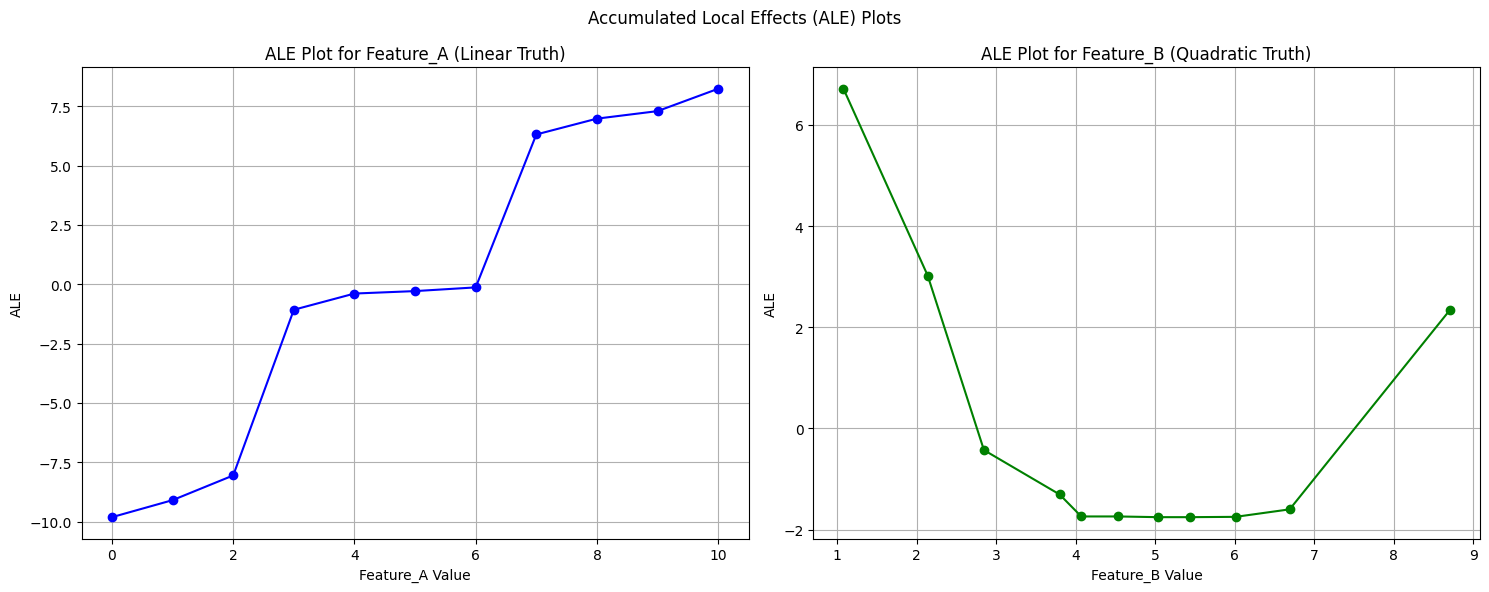

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Feature A
axes[0].plot(grid_a, ale_a, marker='o', color='blue')
axes[0].set_title('ALE Plot for Feature_A (Linear Truth)')
axes[0].set_xlabel('Feature_A Value')
axes[0].set_ylabel('ALE')
axes[0].grid(True)

# Plot Feature B
axes[1].plot(grid_b, ale_b, marker='o', color='green')
axes[1].set_title('ALE Plot for Feature_B (Quadratic Truth)')
axes[1].set_xlabel('Feature_B Value')
axes[1].set_ylabel('ALE')
axes[1].grid(True)

plt.suptitle('Accumulated Local Effects (ALE) Plots')
plt.tight_layout()
plt.show()

## 6. Analysis of Results

The plots above allow us to interpret the model's behavior:

1.  **Linear Effect (Feature_A)**:
    *   The ALE plot for `Feature_A` is a somewhat straight line with a constant positive slope. Note that the line is not perfectly straight due to the small sample size and noise in the data.
    *   This correctly identifies the linear relationship we engineered.
    *   The accumulated effects increase steadily, meaning higher values of A always lead to higher predictions.

2.  **Quadratic Effect (Feature_B)**:
    *   The ALE plot for `Feature_B` shows a parabolic (U-shaped) curve.
    *   The minimum is reached around x = 5, which matches our generation formula ($(B-5)^2$).
    *   This shows that the model has learned that values far from 5 (in either direction) increase the target value.

3.  **Robustness**:
    *   Even with only 50 samples and added noise, ALE provides a smooth and accurate representation of the underlying features.
    *   Though this is slightly more difficult to see with very few samples, the "binning" strategy seems to help average out the noise ($+ \epsilon$). We would expect this phenomenon to be more pronounced with larger datasets (or with less noise).

## 3. Visualizing the ALE Calculation Mechanism

To understand *how* ALE computes these values effectively, let's zoom in on the process for a single bin of `Feature_A`.

The plot below illustrates the core operation:
1.  **Bin Selection**: We focus on a specific interval of `Feature_A` (highlighted in yellow).
2.  **Sample Identification**: We find real data points that fall into this bin (black dots).
3.  **Perturbation**: For each of these points, we replace their `Feature_A` value with the bin's lower limit (red x) and upper limit (green x), while keeping `Feature_B` unchanged.
4.  **Difference Calculation**: We calculate the difference in the model's prediction between these two edges (purple lines). The average of these differences is the "local effect" for this bin.

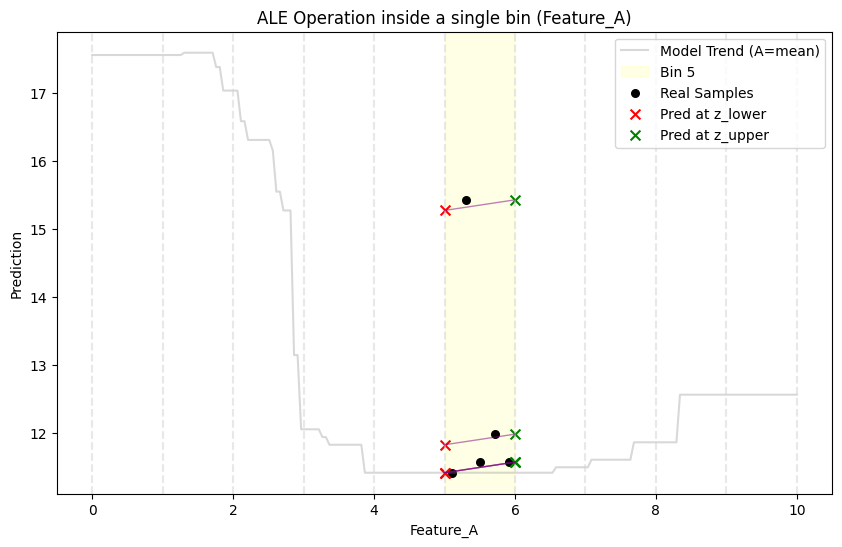

In [13]:
# Select feature to visualize
feature = 'Feature_A'
n_bins = 10
quantiles = np.linspace(0, 1, n_bins + 1)
grid = np.unique(np.quantile(X[feature], quantiles))

# Select a specific bin to highlight (e.g., the middle bin)
bin_idx = 5
z_lower = grid[bin_idx]
z_upper = grid[bin_idx+1]

# Get samples in this bin
indices = X[(X[feature] >= z_lower) & (X[feature] < z_upper)].index
X_subset = X.loc[indices].copy()

# Calculate predictions at edges
X_lower = X_subset.copy()
X_lower[feature] = z_lower
preds_lower = model.predict(X_lower)

X_upper = X_subset.copy()
X_upper[feature] = z_upper
preds_upper = model.predict(X_upper)

plt.figure(figsize=(10, 6))

# 1. Plot the "True" relationship (fixed at mean of A) for context
x_fine = np.linspace(X[feature].min(), X[feature].max(), 200)
X_fine = pd.DataFrame({
    'Feature_A': [X['Feature_A'].mean()]*200, 
    'Feature_B': x_fine
})
plt.plot(x_fine, model.predict(X_fine), color='gray', alpha=0.3, label='Model Trend (A=mean)')

# 2. Plot grid lines
for g in grid:
    plt.axvline(g, color='lightgray', linestyle='--', alpha=0.5)

# 3. Highlight the bin
plt.axvspan(z_lower, z_upper, color='yellow', alpha=0.1, label=f'Bin {bin_idx}')

# 4. Plot calculations
# Original points (approximated location for visualization)
plt.scatter(X_subset[feature], model.predict(X_subset), color='black', s=30, label='Real Samples')

# Lower/Upper predictions
plt.scatter([z_lower]*len(indices), preds_lower, color='red', marker='x', s=50, label='Pred at z_lower')
plt.scatter([z_upper]*len(indices), preds_upper, color='green', marker='x', s=50, label='Pred at z_upper')

# Draw lines for the "partial difference"
for i in range(len(indices)):
    plt.plot([z_lower, z_upper], [preds_lower[i], preds_upper[i]], color='purple', alpha=0.5, linewidth=1)

plt.title(f'ALE Operation inside a single bin ({feature})')
plt.xlabel(feature)
plt.ylabel('Prediction')
plt.legend()
plt.show()